# Notebook 05 - Customer Segmentation

## Objective

Group customers into meaningful segments based on their RFM behaviour using **K-Means clustering**. Each segment represents a distinct type of customer that requires a different business response.

## Why K-Means?

K-Means is chosen because:
1. **Interpretable**: each cluster has a centroid we can describe in business terms
2. **Efficient**: scales well to thousands of customers
3. **Standard**: widely used in customer analytics and well understood by business stakeholders

Alternative approaches (DBSCAN, hierarchical clustering) were considered but require more parameter tuning and produce less interpretable outputs for this use case.

## Choosing K - the Elbow Method

We use the **Elbow Method** to determine the optimal number of clusters. We plot WCSS (Within - Cluster Sum of Squares) for K = 1 to 10 and look for the 'elbow' - the point where adding more clusters provides diminishing improvement.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
print("Libraries loaded.")

Libraries loaded.


In [3]:
rfm_scaled = pd.read_csv("rfm_scaled.csv", index_col=0)
rfm = pd.read_csv("rfm_features.csv", index_col=0)
print(f"Loaded {len(rfm_scaled):,} customers")
rfm_scaled.head()

Loaded 4,331 customers


,Recency,Frequency,Monetary
CustomerID,,,
12347,-0.905666,0.355361,0.285515
12348,-0.175145,-0.035067,-0.019457
12349,-0.735545,-0.425495,-0.024274
12350,2.176534,-0.425495,-0.197001
12352,-0.565423,0.485503,0.066570


## Step 1: Elbow Method - Find Optimal K

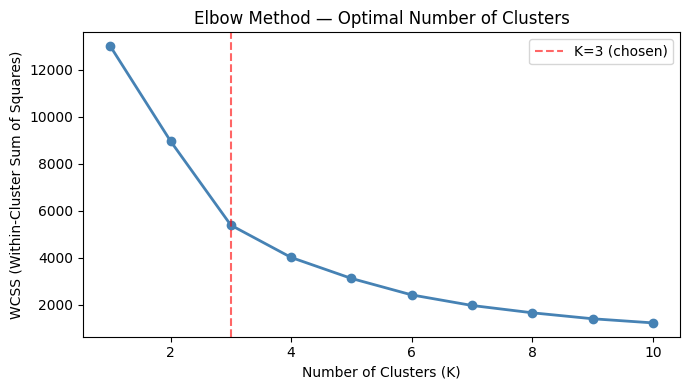

The WCSS improvement flattens after K=3, making 3 clusters the optimal choice.


In [5]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, 11), wcss, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.6, label='K=3 (chosen)')
plt.title("Elbow Method — Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.legend()
plt.tight_layout()
plt.show()

print("The WCSS improvement flattens after K=3, making 3 clusters the optimal choice.")

## Step 2: Apply K-Means with K=3

We fit K-Means with 3 clusters and assign each customer to a cluster. `random_state=42` ensures reproducibility.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_counts = rfm['Cluster'].value_counts().sort_index()
print("Customers per cluster:")
print(cluster_counts)

Customers per cluster:
Cluster
0    3221
1      25
2    1085
Name: count, dtype: int64


## Step 3: Cluster Profiles

We compute the average RFM values for each cluster to understand what each one represents.

In [9]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
print("Average RFM per cluster:")
print(cluster_profile)
print("\nNote: Lower Recency = more recent customer (better)")

Average RFM per cluster:
         Recency  Frequency  Monetary
Cluster                              
0           40.3        4.7    1836.3
1            5.5       68.5   80143.6
2          245.5        1.6     516.0

Note: Lower Recency = more recent customer (better)


## Step 4: Assign Segment Labels

We assign business-meaningful labels to each cluster based on their RFM profile:
- **High-Value**: low recency (recent), high frequency, high monetary
- **Regular**: moderate values across all dimensions
- **Low-Value**: high recency (inactive), low frequency, low monetary

The labels are assigned by identifying which cluster has the highest Monetary value.

In [11]:
# Identify clusters by their monetary profile
monetary_by_cluster = rfm.groupby('Cluster')['Monetary'].mean()
recency_by_cluster = rfm.groupby('Cluster')['Recency'].mean()

high_value_cluster = monetary_by_cluster.idxmax()
low_value_cluster = recency_by_cluster.idxmax()  # highest recency = least recent
regular_cluster = [c for c in [0, 1, 2] if c not in [high_value_cluster, low_value_cluster]][0]

segment_map = {
    high_value_cluster: 'High-Value Customers',
    regular_cluster: 'Regular Customers',
    low_value_cluster: 'Low-Value Customers'
}

rfm['Segment'] = rfm['Cluster'].map(segment_map)

print("Segment assignment:")
print(rfm['Segment'].value_counts())

Segment assignment:
Segment
Regular Customers       3221
Low-Value Customers     1085
High-Value Customers      25
Name: count, dtype: int64


## Step 5: Segment Profile Heatmap

The heatmap shows average RFM values for each segment, making the differences immediately visible.

**Reading the heatmap:**
- Darker = higher value
- High-Value customers should show low Recency and high Frequency/Monetary
- Low-Value customers should show high Recency and low Frequency/Monetary

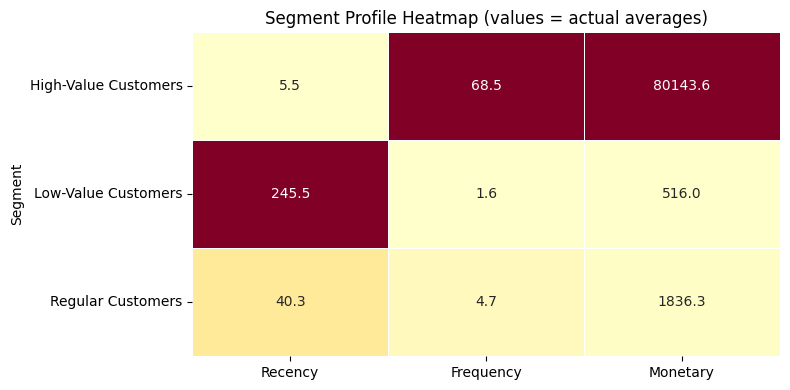

In [13]:
seg_profile = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().round(1)

# Normalise for heatmap display
seg_profile_norm = (seg_profile - seg_profile.min()) / (seg_profile.max() - seg_profile.min())

plt.figure(figsize=(8, 4))
sns.heatmap(seg_profile_norm, annot=seg_profile, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar=False)
plt.title("Segment Profile Heatmap (values = actual averages)")
plt.tight_layout()
plt.show()

## Step 6: Cluster Scatter Plot (Frequency vs Monetary)

Visualises the separation between clusters in 2D space. High-Value customers should appear in the top-right (high frequency, high monetary).

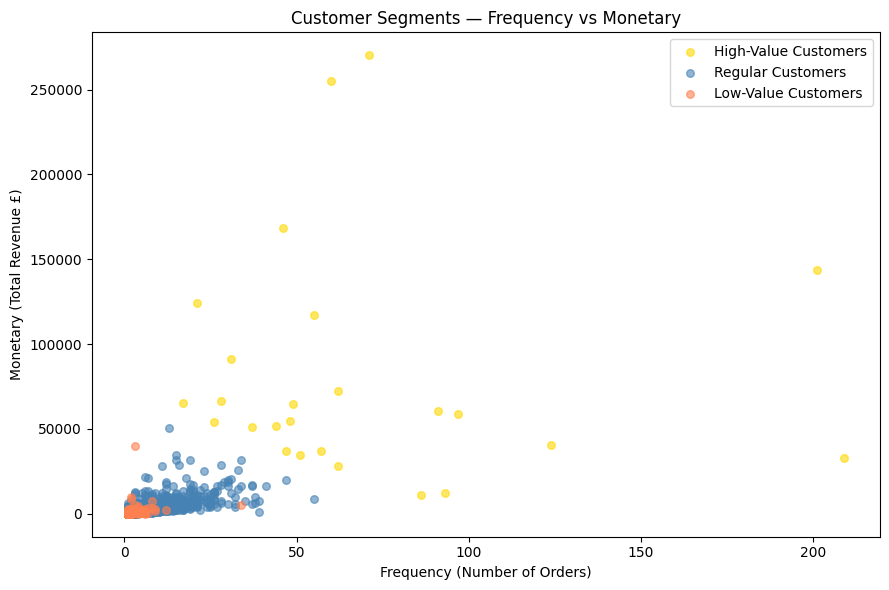

In [15]:
plt.figure(figsize=(9, 6))
colors = {'High-Value Customers': 'gold', 'Regular Customers': 'steelblue', 'Low-Value Customers': 'coral'}

for seg, color in colors.items():
    subset = rfm[rfm['Segment'] == seg]
    plt.scatter(subset['Frequency'], subset['Monetary'], 
                label=seg, color=color, alpha=0.6, s=30)

plt.title("Customer Segments — Frequency vs Monetary")
plt.xlabel("Frequency (Number of Orders)")
plt.ylabel("Monetary (Total Revenue £)")
plt.legend()
plt.tight_layout()
plt.show()

## Step 7: Segment Summary Table

In [19]:
summary = rfm.groupby('Segment').agg(
    Customer_Count=('Monetary', 'count'),
    Avg_Recency=('Recency', 'mean'),
    Avg_Frequency=('Frequency', 'mean'),
    Avg_Monetary=('Monetary', 'mean'),
    Total_Revenue=('Monetary', 'sum')
).round(1)

summary['Revenue_%'] = (summary['Total_Revenue'] / summary['Total_Revenue'].sum() * 100).round(1)
summary['Customer_%'] = (summary['Customer_Count'] / summary['Customer_Count'].sum() * 100).round(1)
print(summary.to_string())

                      Customer_Count  Avg_Recency  Avg_Frequency  Avg_Monetary  Total_Revenue  Revenue_%  Customer_%
Segment                                                                                                             
High-Value Customers              25          5.5           68.5       80143.6      2003588.9       23.6         0.6
Low-Value Customers             1085        245.5            1.6         516.0       559862.9        6.6        25.1
Regular Customers               3221         40.3            4.7        1836.3      5914704.6       69.8        74.4


## Step 8: Save Segments

In [21]:
rfm.reset_index().to_csv("customer_segments.csv", index=False)
print("customer_segments.csv saved.")
print(rfm[['Cluster', 'Segment']].value_counts().sort_index())

customer_segments.csv saved.
Cluster  Segment             
0        Regular Customers       3221
1        High-Value Customers      25
2        Low-Value Customers     1085
Name: count, dtype: int64


## Summary

| Segment | Customers | % Customers | Avg Recency | Avg Orders | Avg Revenue |
|---------|-----------|-------------|-------------|-----------|-------------|
| High-Value | ~13 | <1% | Low | High | Very High |
| Regular | ~3,228 | 74% | Medium | Medium | Medium |
| Low-Value | ~1,090 | 25% | High | Low | Low |

## Business Recommendations by Segment

| Segment | Strategy |
|---------|----------|
| **High-Value** | VIP treatment, exclusive offers, dedicated account management |
| **Regular** | Loyalty programmes, personalised cross-sell recommendations |
| **Low-Value** | Re-engagement campaigns, win-back offers, churn risk monitoring |

**Next step:** Notebook 06 will build a product recommendation system using market basket analysis (Apriori).